# Initial Soil Spatial Autocorrelation Tests

This notebook initializes the `HybridEcosystem` model and tests the initial soil nutrient maps for spatial correlation using Moran's I and an empirical variogram.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from libpysal.weights import lat2W
    from esda.moran import Moran
except ImportError:
    raise ImportError('Please install libpysal and esda: pip install libpysal esda')

try:
    from scipy.spatial.distance import pdist
except ImportError:
    raise ImportError('Please install scipy: pip install scipy')

C:\Users\f.andrade\AppData\Local\anaconda3\envs\elementalworld\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [28]:
class HybridEcosystem:
    def __init__(self, height, width, max_agents, niche_centers, niche_covariances,
                 growth_rate=0.7, respiration_rate=0.02, turnover_rate=0.02,
                 mineralization_rate=0.05, seed_cost=0.3, seed_mass=0.05,
                 K_biomass=1.5, soil_base_ratio=None, soil_pool_mean=1.0,
                 soil_pool_std=0.01, soil_ratio_noise=0.05, soil_input_rate=0.2,
                 input_drift_scale=0.08, soil_availability_rate=[1.0, 1.0, 1.0, 1.0],
                 sigma_threshold=3.0,
                 catastrophe_interval=200, catastrophe_mortality=0.4,
                 p_disturbance=0.01, disturbance_radius=8, disturbance_strength=0.7,
                 demo_noise_std=0.003):

        self.H = height
        self.W = width
        self.MAX_AGENTS = max_agents

        niche_centers_norm = niche_centers / np.sum(niche_centers, axis=1, keepdims=True)
        self.niche_centers = tf.constant(niche_centers_norm, dtype=tf.float32, name='Niche_Centers')
        self.N_spp = self.niche_centers.shape[0]

        self.tolerance_cov = tf.constant(niche_covariances, dtype=tf.float32, name='Niche_Covariances')
        self.tolerance_inv = tf.linalg.inv(self.tolerance_cov)

        self.soil_availability_rate = tf.reshape(
            tf.constant(soil_availability_rate, dtype=tf.float32), [1, 1, 4])
        self.sigma_threshold = sigma_threshold

        self.soil_input_rate = soil_input_rate
        if soil_base_ratio is None:
            self.soil_base_ratio = np.array([0.4, 0.3, 0.2, 0.1])
        else:
            self.soil_base_ratio = np.array(soil_base_ratio, dtype=np.float32)

        # 1) raw i.i.d. noise
        raw_noise = tf.random.normal((self.H, self.W, 4), mean=0.0, stddev=soil_ratio_noise)

        # 2) build a separable Gaussian-like kernel for smoothing
        #    kernel_size controls correlation length (e.g. 5, 7, 9)
        kernel_size = 3
        sigma = 1.0

        ax = tf.range(kernel_size, dtype=tf.float32) - (kernel_size - 1)/2.0
        gauss_1d = tf.exp(-0.5 * (ax / sigma)**2)
        gauss_1d = gauss_1d / tf.reduce_sum(gauss_1d)

        gauss_2d = gauss_1d[:, None] * gauss_1d[None, :]          # (k, k)
        gauss_2d = gauss_2d[:, :, tf.newaxis, tf.newaxis]         # (k, k, 1, 1)
        gauss_2d = tf.tile(gauss_2d, [1, 1, 4, 1])                # (k, k, 4, 1) depthwise

        # 3) depthwise conv to smooth noise per nutrient
        raw_noise_4d = raw_noise[tf.newaxis, ...]                 # (1, H, W, 4)

        smoothed_noise = tf.nn.depthwise_conv2d(
            raw_noise_4d,
            gauss_2d,
            strides=[1, 1, 1, 1],
            padding="SAME"
        )[0]                                                      # (H, W, 4)

        # rescale to roughly match desired stddev
        std_before = tf.math.reduce_std(smoothed_noise)
        smoothed_noise = smoothed_noise * (soil_ratio_noise / (std_before + 1e-9))

        alpha = 0.5  # 0 = pure raw, 1 = pure smooth; try 0.3–0.7
        noise = alpha * smoothed_noise + (1.0 - alpha) * raw_noise
        base_tiled = tf.tile(
            tf.constant(self.soil_base_ratio, dtype=tf.float32)[tf.newaxis, tf.newaxis, :],
            [self.H, self.W, 1])
        ratio_raw = tf.maximum(0.001, base_tiled + noise)
        init_inorg_ratio = ratio_raw / tf.reduce_sum(ratio_raw, axis=2, keepdims=True)
        pool_size = tf.maximum(0.5, tf.random.normal(
            (self.H, self.W, 1), mean=soil_pool_mean, stddev=soil_pool_std))
        init_inorg = init_inorg_ratio * pool_size
        self.soil = tf.Variable(
            tf.concat([init_inorg, tf.zeros((self.H, self.W, 4))], axis=-1), name='Soil')


In [29]:
def morans_i_2d(arr):
    h, w = arr.shape
    weights = lat2W(h, w, rook=False)
    mi = Moran(arr.flatten(), weights)
    return mi.I, mi.p_sim

def empirical_variogram(arr, max_lag=20, n_bins=15):
    h, w = arr.shape
    y, x = np.indices((h, w))
    coords = np.column_stack([x.ravel(), y.ravel()])
    vals = arr.ravel()

    dists = pdist(coords)
    sqdiff = pdist(vals[:, None], metric='sqeuclidean')

    bins = np.linspace(0, max_lag, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    gamma = np.full(n_bins, np.nan)

    for i in range(n_bins):
        mask = (dists >= bins[i]) & (dists < bins[i+1])
        if np.any(mask):
            gamma[i] = 0.5 * np.mean(sqdiff[mask])

    return bin_centers, gamma


In [30]:
tf.random.set_seed(42)
np.random.seed(42)

niche_centers = np.array([
    [0.4192, 0.0208, 0.0014, 0.0077, 0.5509],
    [0.4282, 0.0201, 0.0011, 0.0097, 0.5408],
    [0.4020, 0.0223, 0.0011, 0.0072, 0.5674],
    [0.4400, 0.0267, 0.0014, 0.0097, 0.5221],
    [0.3839, 0.0195, 0.0017, 0.0055, 0.5894],
], dtype=np.float32)

niche_covariances = np.array([
  [[0.00027, -0.00011, -0.00001, -0.00001, -0.00009], [-0.00011, 0.00014, 0.00001, 0.00001, 0.00001], [-0.00001, 0.00001, 0.00006, 0.00000, -0.00000], [-0.00001, 0.00001, 0.00000, 0.00007, -0.00001], [-0.00009, 0.00001, -0.00000, -0.00001, 0.00015]],
  [[0.00049, -0.00003, -0.00000, -0.00004, -0.00033], [-0.00003, 0.00009, 0.00000, -0.00000, 0.00002], [-0.00000, 0.00000, 0.00008, 0.00000, 0.00000], [-0.00004, -0.00000, 0.00000, 0.00010, 0.00002], [-0.00033, 0.00002, 0.00000, 0.00002, 0.00037]],
  [[0.00098, 0.00002, 0.00000, 0.00000, -0.00087], [0.00002, 0.00015, 0.00000, 0.00001, -0.00005], [0.00000, 0.00000, 0.00013, 0.00000, -0.00000], [0.00000, 0.00001, 0.00000, 0.00014, -0.00002], [-0.00087, -0.00005, -0.00000, -0.00002, 0.00108]],
  [[0.00053, -0.00000, 0.00000, 0.00003, -0.00045], [-0.00000, 0.00016, 0.00000, 0.00001, -0.00007], [0.00000, 0.00000, 0.00010, 0.00000, -0.00000], [0.00003, 0.00001, 0.00000, 0.00010, -0.00004], [-0.00045, -0.00007, -0.00000, -0.00004, 0.00067]],
  [[0.00047, 0.00002, -0.00001, -0.00001, -0.00038], [0.00002, 0.00010, 0.00000, 0.00000, -0.00003], [-0.00001, 0.00000, 0.00009, 0.00000, 0.00000], [-0.00001, 0.00000, 0.00000, 0.00010, 0.00000], [-0.00038, -0.00003, 0.00000, 0.00000, 0.00050]]
], dtype=np.float32)

model = HybridEcosystem(
    height=100, width=100, max_agents=100000,
    niche_centers=niche_centers,
    niche_covariances=niche_covariances
)
soil0 = model.soil.numpy()
inorg0 = soil0[:, :, :4]
nutrient_names = ['N', 'P', 'K', 'O']

In [31]:
results = []
for i, name in enumerate(nutrient_names):
    I, p = morans_i_2d(inorg0[:, :, i])
    results.append((name, I, p))

results

[('N', 0.3570988417998967, 0.001),
 ('P', 0.3614588128211459, 0.001),
 ('K', 0.35132927566804323, 0.001),
 ('O', 0.3676429380388528, 0.001)]

In [32]:
import pandas as pd
pd.DataFrame(results, columns=['Nutrient', 'Morans_I', 'p_value'])

,Nutrient,Morans_I,p_value
0,N,0.357099,0.001
1,P,0.361459,0.001
2,K,0.351329,0.001
3,O,0.367643,0.001


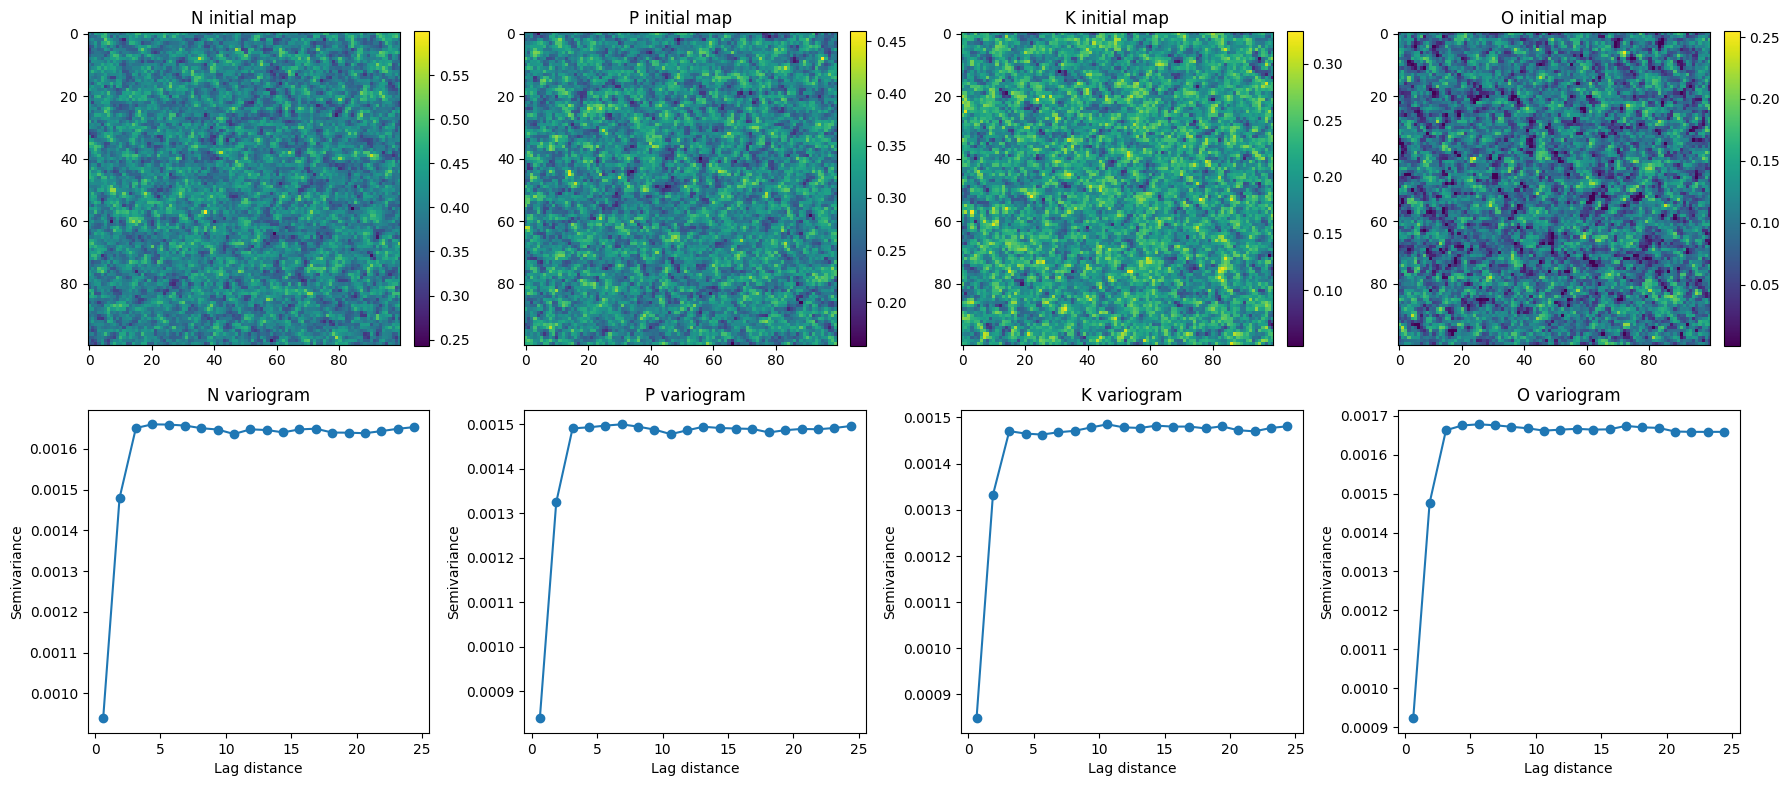

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, name in enumerate(nutrient_names):
    arr = inorg0[:, :, i]
    ax1 = axes[0, i]
    im = ax1.imshow(arr, cmap='viridis')
    ax1.set_title(f'{name} initial map')
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    lags, gamma = empirical_variogram(arr, max_lag=25, n_bins=20)
    ax2 = axes[1, i]
    ax2.plot(lags, gamma, marker='o')
    ax2.set_title(f'{name} variogram')
    ax2.set_xlabel('Lag distance')
    ax2.set_ylabel('Semivariance')

plt.tight_layout()
plt.show()